[2026-07-26 17:14:26] [info     ] 计算四大金刚因子(轻量版)，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-26 17:14:52] [info     ] 因子形状: (242000, 3)
        date instrument    factor
0 2024-01-02  000006.SZ  0.302321
1 2024-01-02  000012.SZ  0.380274
2 2024-01-02  000016.SZ  0.280875
3 2024-01-02  000019.SZ  0.395388
4 2024-01-02  000025.SZ  0.347167
count    242000.000000
mean          0.265057
std           0.078102
min          -0.317757
25%           0.220682
50%           0.271039
75%           0.317820
max           0.515261
Name: factor, dtype: float64
[2026-07-26 17:14:52] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-26 17:14:56] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-26 17:14:56] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-26 17:14:56] [info     ] ========== 数据检查 ==========
[2026-07-26 17:14:56] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'tur

时段,IC
2024-01-15~2024-02-08,0.0205
2024-09-24~2024-10-08,0.0126

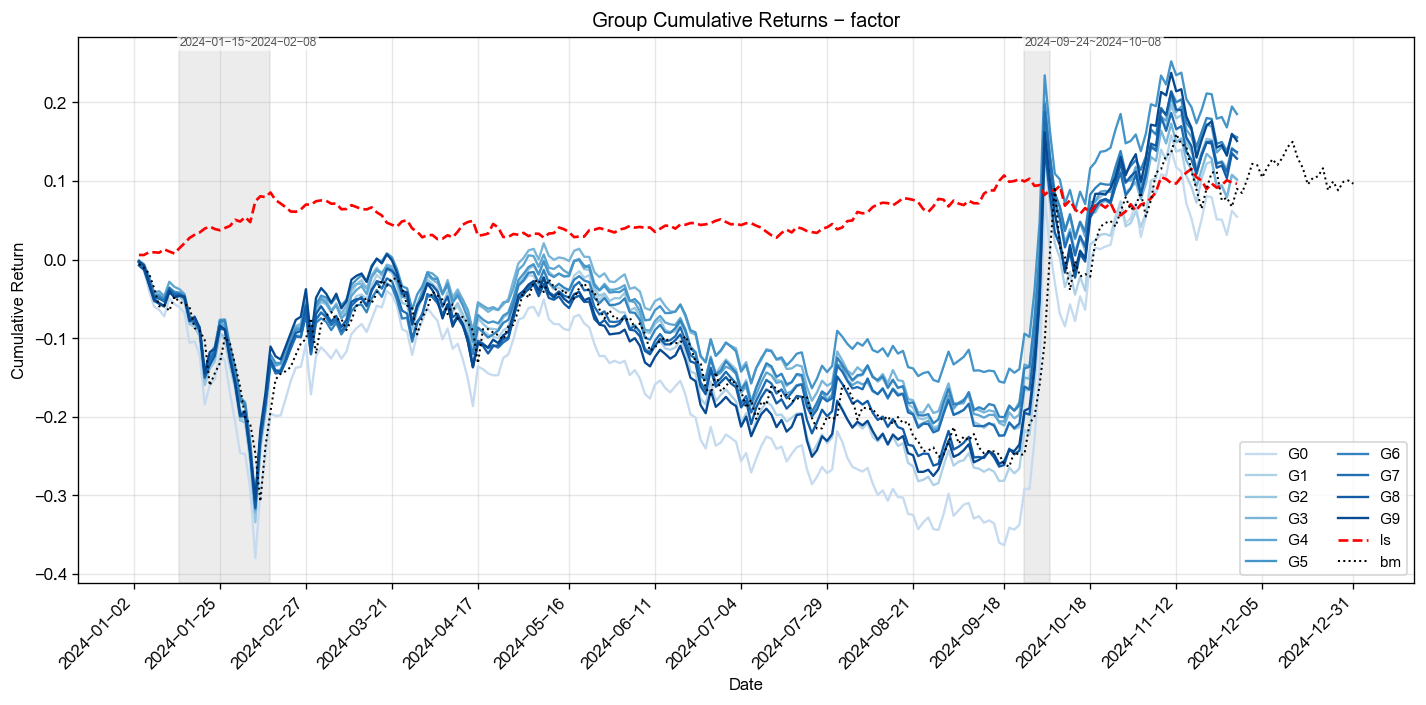
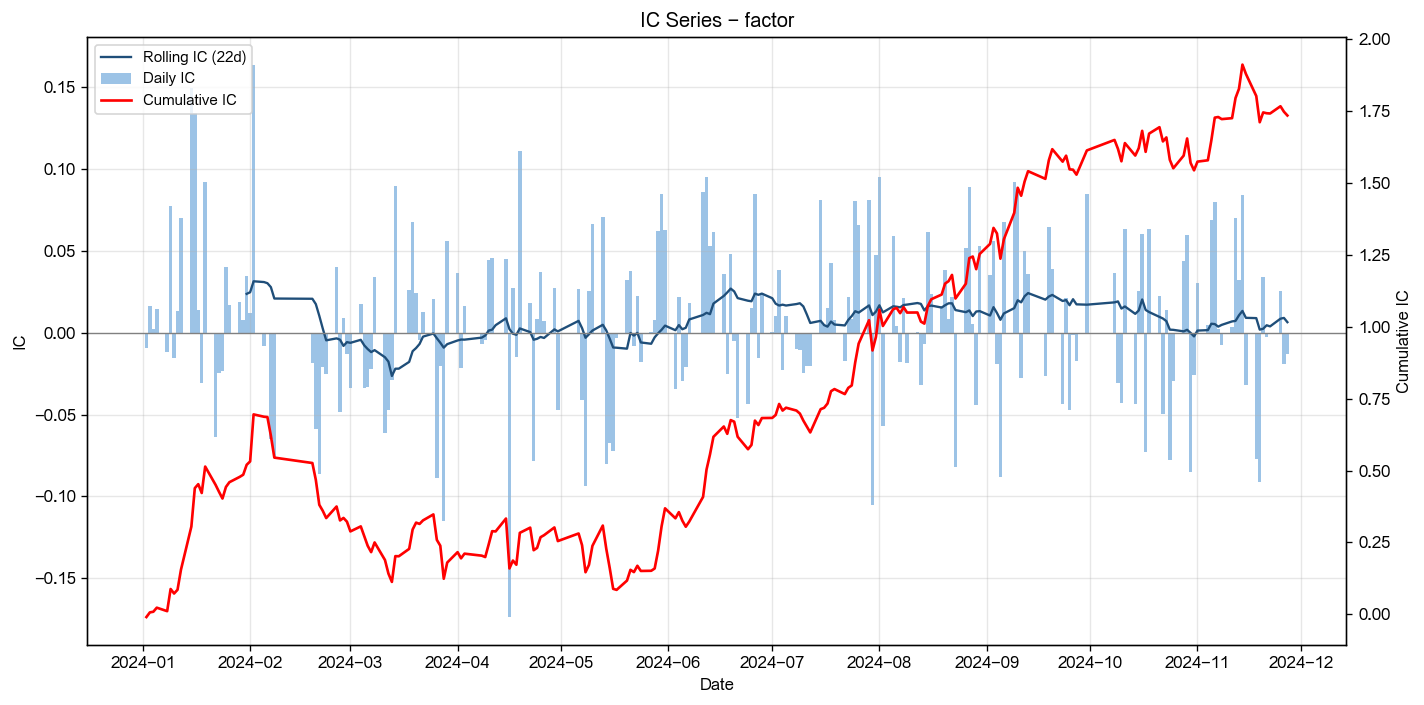
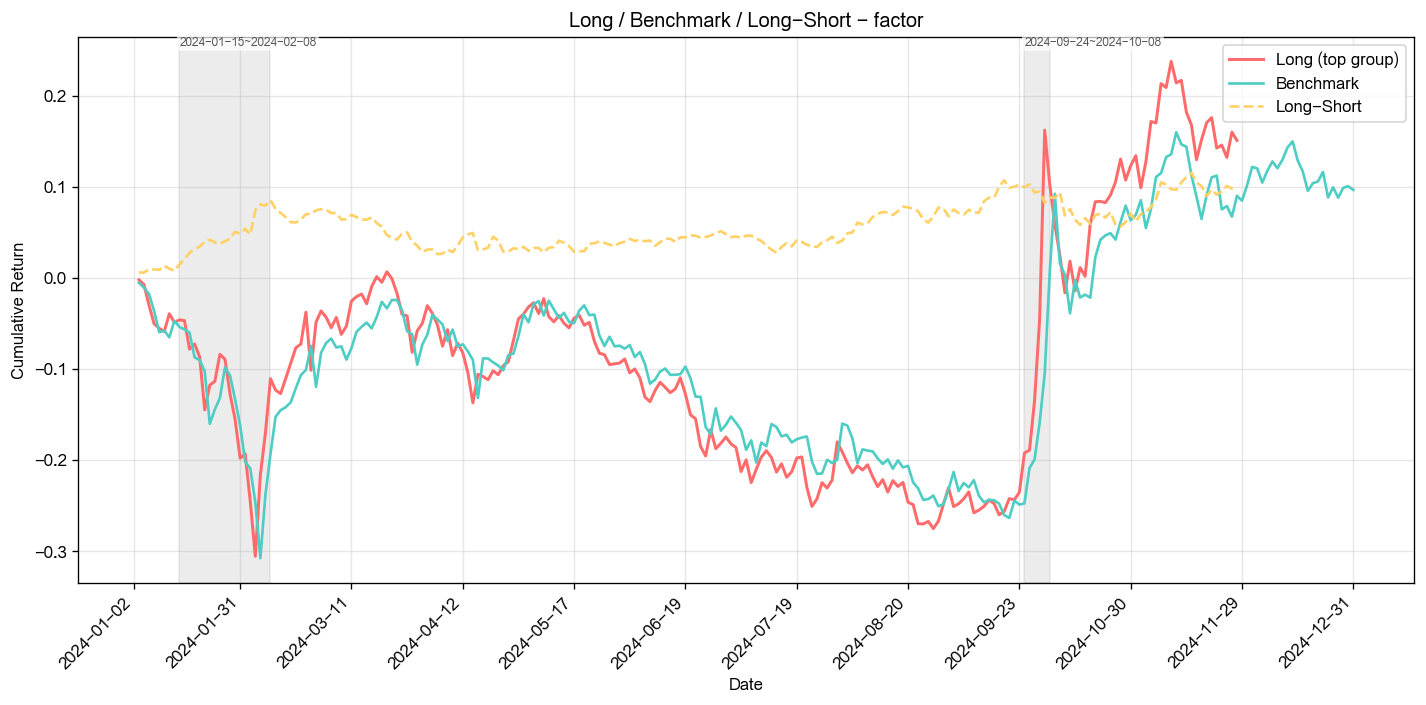
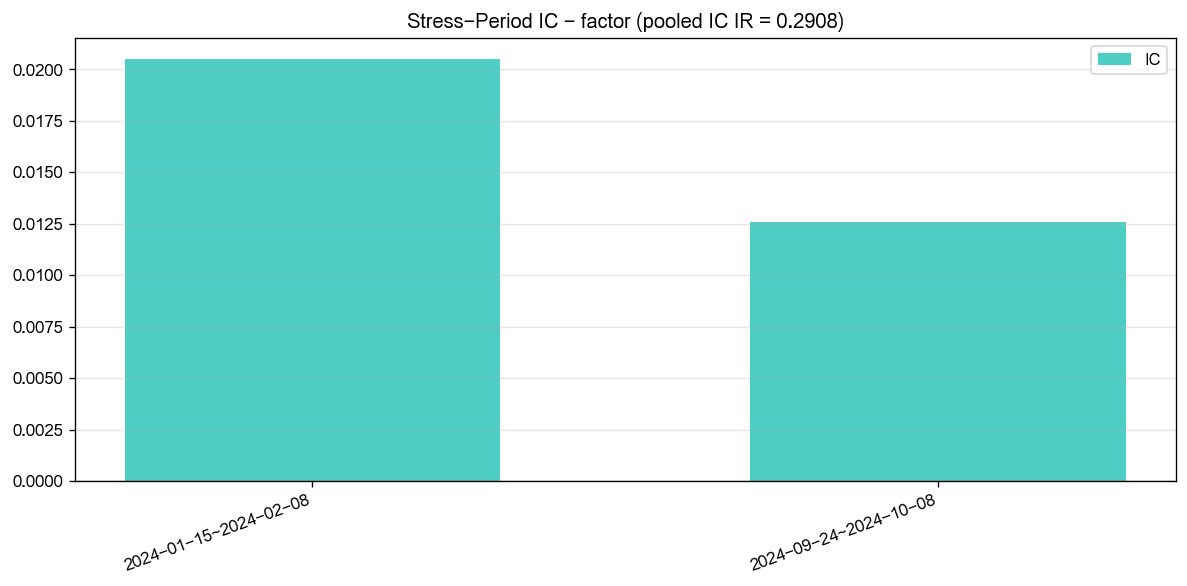
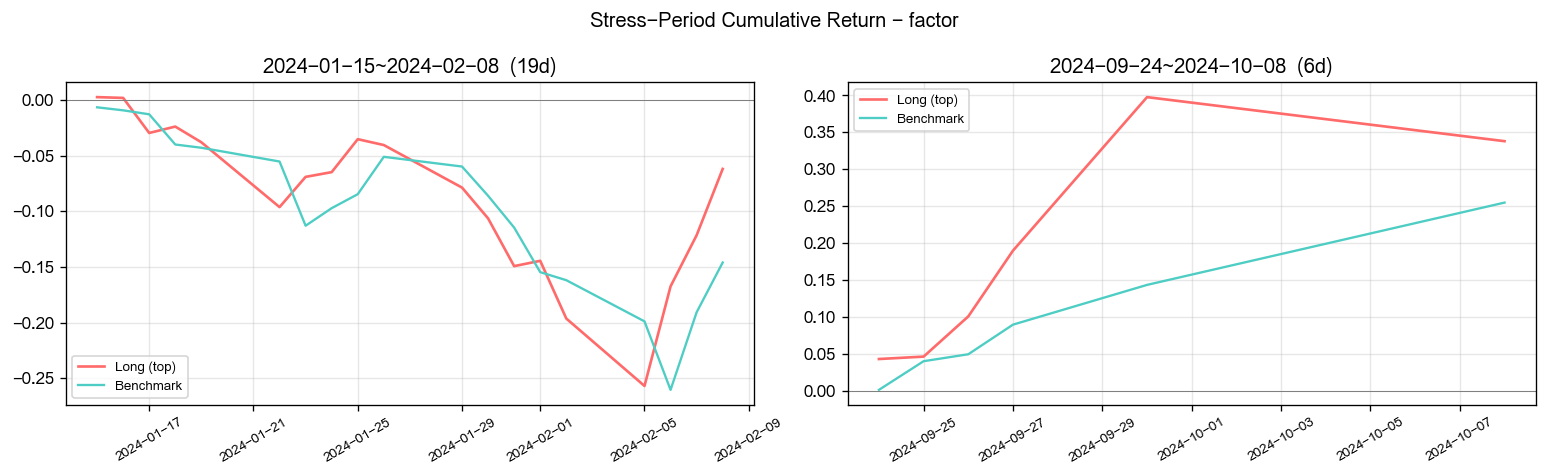

[2026-07-26 17:18:16] [info     ] ========== 因子池回归 ==========
[2026-07-26 17:18:16] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-26 17:18:17] [info     ] 获取收益率数据, 耗时: 0.8921 秒
[2026-07-26 17:18:18] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.56 秒
[2026-07-26 17:18:18] [info     ] 统计 回归结果, 耗时: 0.0096 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8926,0.0441,0.0233,1.0000
2,amount,1.6831,0.0183,0.0109,0.9000
3,netflow_amount_main,1.5127,0.0252,0.0166,1.0000
4,gross_profit_rate_ttm,1.5083,0.0070,0.0046,1.0000
5,netflow_amount_rate_main,1.5082,0.0097,0.0065,1.0000
6,bias_20,1.4469,0.0293,0.0203,0.9000
7,pb,1.4279,0.0096,0.0067,1.0000
8,net_profit_rate_ttm,1.3985,0.0040,0.0029,0.8000
9,cci_14,1.3640,0.0335,0.0246,0.9000
10,pe_ttm,1.3444,0.0029,0.0022,0.9000

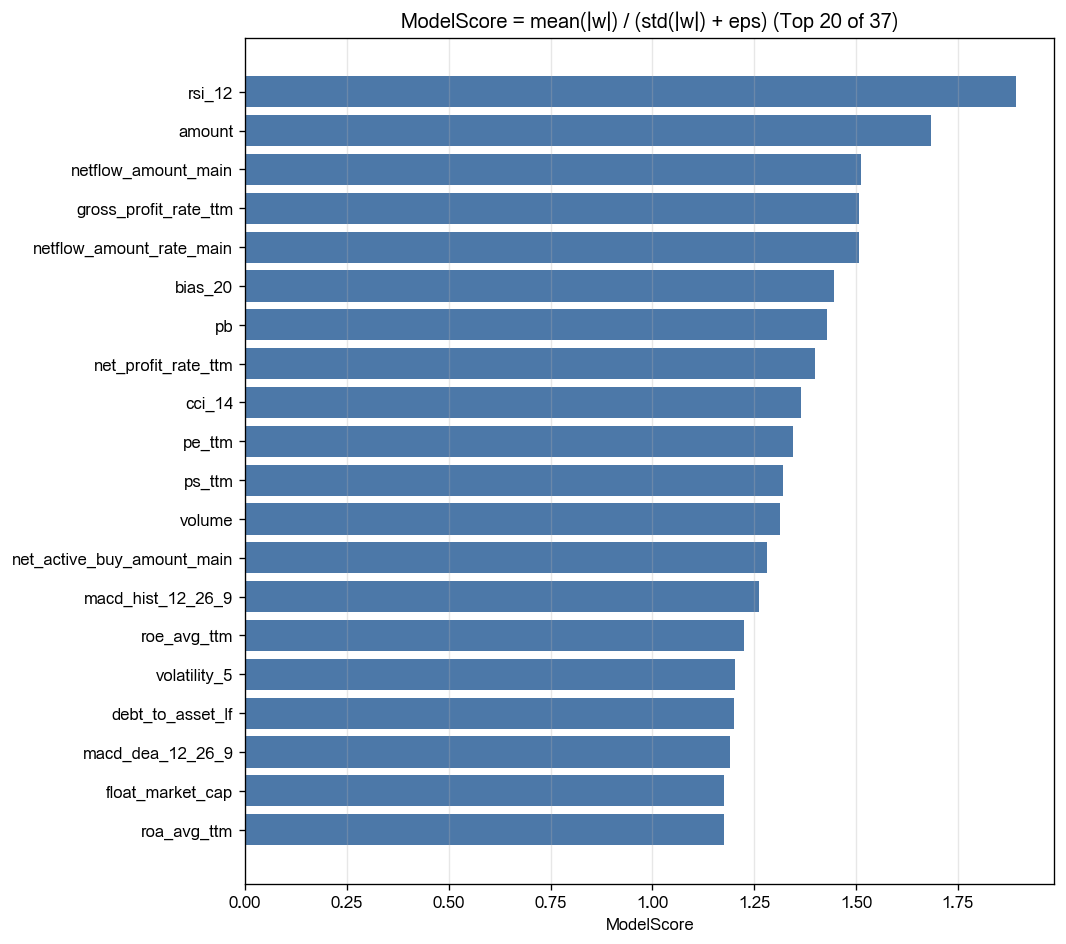
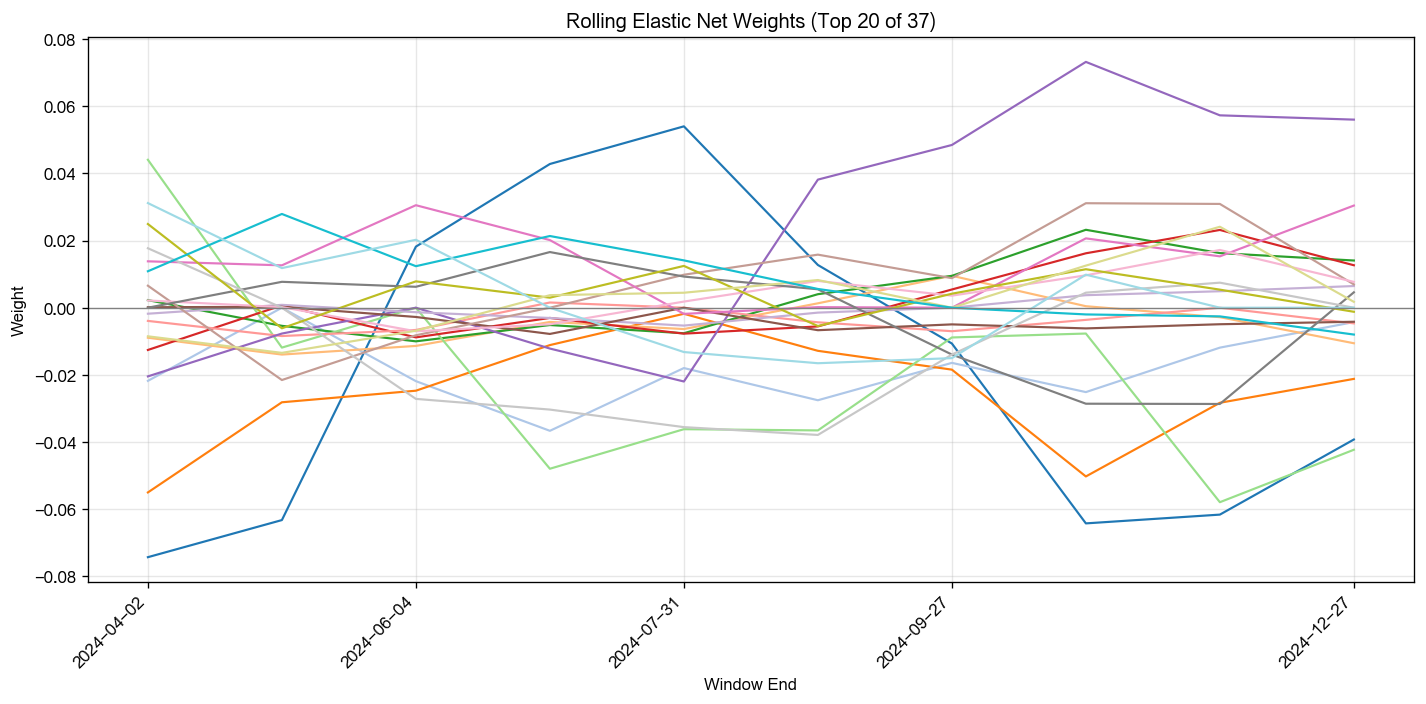
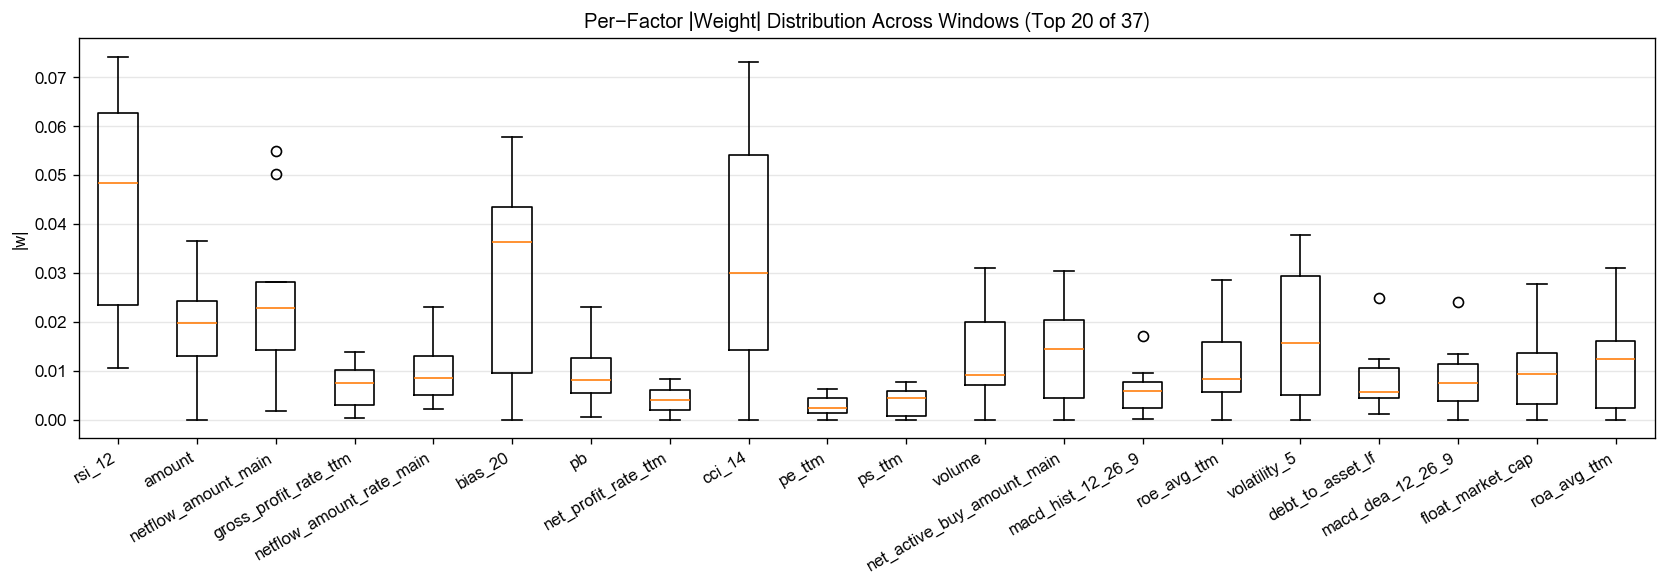
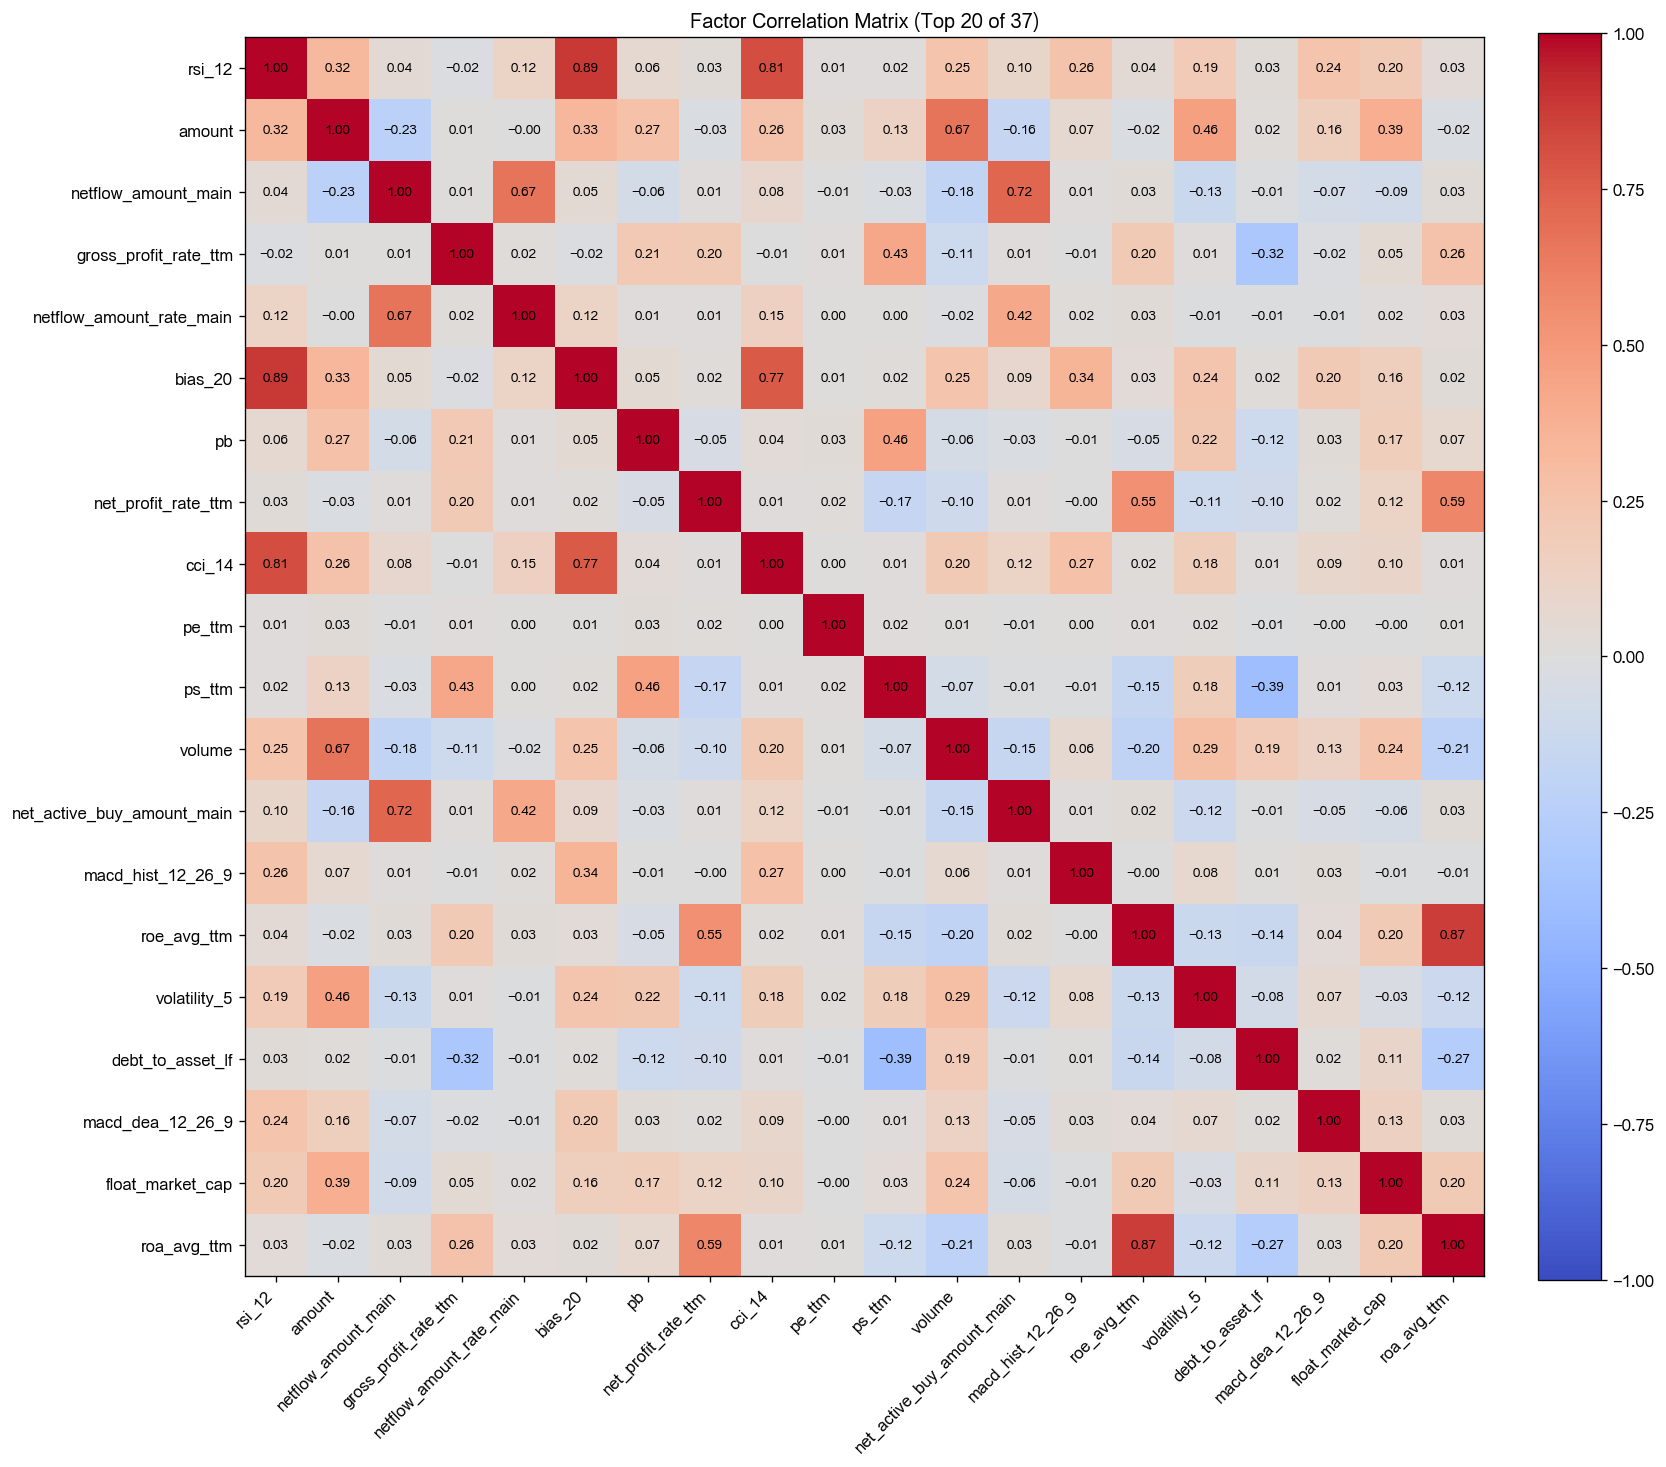

[2026-07-26 17:18:21] [warning  ] 返回的Outputs实例(size=35220362) 大于 64K, 将不会被缓存
[2026-07-26 17:18:21] [info     ] bigalpha_eval.v4 运行完成 [205.333s].


In [1]:
import pandas as pd
import numpy as np
import dai


def main(datasources, start_date, end_date):
    """
    ============================================================
    因子名称：四大金刚综合因子（轻量版）
              (Four Pillars Composite Factor - Lite)
    赛道：传统量化赛道

    【经济逻辑】
    金刚1（多头）：龙头带队扩散 — 全市场龙头涨+后排跟涨
    金刚2（多头）：分歧回流韧性 — 回撤日抗跌+回流+回收
    金刚3（风控）：波动拥挤 — 20日收益波动率高=拥挤
    金刚4（风控）：资金异动拥挤 — 成交额对数变化波动率高=拥挤
    最终因子 = 0.5×金刚1 + 0.5×金刚2 - 0.3×金刚3 - 0.2×金刚4
    ============================================================
    """
    bar1m = datasources["bar1m"]

    LOOKBACK_DAYS = 90
    query_start = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)).strftime('%Y-%m-%d %H:%M:%S')

    # ============================================================
    # [Step 1] 日线聚合
    # ============================================================
    sql = f"""
    WITH daily_bar AS (
        SELECT
            CAST(date::DATE AS DATETIME) AS date,
            instrument,
            FIRST(open ORDER BY date)   AS open,
            MAX(high)                   AS high,
            MIN(low)                    AS low,
            LAST(close ORDER BY date)   AS close,
            SUM(volume)                 AS volume,
            SUM(amount)                 AS amount
        FROM {bar1m}
        WHERE close > 0
        GROUP BY date::DATE, instrument
    )
    SELECT *
    FROM daily_bar
    """
    df = dai.query(sql, filters={'date': [query_start, end_date]}, compression=True).df()
    if df.empty:
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    for col in ['open', 'high', 'low', 'close', 'volume', 'amount']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ============================================================
    # [Step 2] 基础计算
    # ============================================================
    df['daily_ret'] = df.groupby('instrument')['close'].pct_change().fillna(0)
    df['ret_5d'] = df.groupby('instrument')['close'].pct_change(5).fillna(0)
    df['ret_20d'] = df.groupby('instrument')['close'].pct_change(20).fillna(0)

    # 20日均成交额
    df['amount_ma20'] = (
        df.groupby('instrument')['amount']
        .rolling(20, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )

    # 成交额对数变化
    df['amount_log_diff'] = np.log(
        df['amount'] / (df.groupby('instrument')['amount'].shift(1) + 1e-8)
    ).fillna(0)

    # 全市场等权收益
    market_daily = df.groupby('date')['daily_ret'].mean()
    df['market_ret'] = df['date'].map(market_daily).fillna(0)

    # ============================================================
    # 金刚1：龙头带队扩散
    # ============================================================
    pillar1_map = {}
    for date, day_data in df.groupby('date'):
        n_stocks = len(day_data)
        if n_stocks < 30:
            pillar1_map[date] = 0.3
            continue

        amt_th = day_data['amount_ma20'].quantile(0.8)
        ret_th = day_data['ret_5d'].quantile(0.8)
        is_leader = (day_data['amount_ma20'] >= amt_th) & (day_data['ret_5d'] >= ret_th)
        n_leaders = is_leader.sum()

        if n_leaders >= 5:
            ls_norm = np.clip(day_data.loc[is_leader, 'ret_5d'].mean() / 0.15, 0, 1)
            nl = ~is_leader
            fw = (day_data.loc[nl, 'daily_ret'] > day_data.loc[nl, 'market_ret']).mean() if nl.sum() > 0 else 0.5
            pillar1_map[date] = ls_norm * fw
        else:
            pillar1_map[date] = 0.3

    df['pillar1'] = df['date'].map(pillar1_map).fillna(0.3)

    # ============================================================
    # 金刚2：分歧回流韧性
    # ============================================================
    def calc_pillar2(stock_df):
        stock_df = stock_df.sort_values('date').reset_index(drop=True)
        n = len(stock_df)
        if n < 20:
            stock_df['pillar2'] = 0.5
            return stock_df

        c = stock_df['close'].values
        h = stock_df['high'].values
        l = stock_df['low'].values
        dr = stock_df['daily_ret'].values
        mr = stock_df['market_ret'].values

        is_sd = dr < 0
        is_md = mr < 0
        dd = is_sd & is_md
        excess = dr - mr

        res = np.where(dd, np.clip(excess * 60 + 0.5, 0, 1),
                       np.where(is_md & ~is_sd, 0.7, 0.5))

        flow = np.zeros(n)
        for i in range(1, n):
            if dd[i-1]:
                flow[i] = np.clip(excess[i] * 60 + 0.5, 0, 1)

        rng = h - l
        cp = np.clip(np.where(rng > 0, (c - l) / rng, 0.5), 0, 1)
        rec = np.where(is_sd, cp, np.where(is_md & ~is_sd, 0.7, 0.5))

        combined = 0.35 * res + 0.35 * flow + 0.30 * rec
        stock_df['pillar2'] = pd.Series(combined).rolling(10, min_periods=1).mean().values
        return stock_df

    df = df.groupby('instrument', group_keys=False).apply(calc_pillar2)

    # ============================================================
    # 金刚3：波动拥挤（20日收益波动率，替代相关性）
    # 波动率越高=越不稳定=拥挤风险越大
    # ============================================================
    df['vol_20d'] = (
        df.groupby('instrument')['daily_ret']
        .rolling(20, min_periods=10).std()
        .reset_index(level=0, drop=True)
    ).fillna(0.02)

    # 归一化：波动率2%=0分，10%=1分
    df['pillar3'] = np.clip((df['vol_20d'] - 0.02) / 0.08, 0, 1)

    # ============================================================
    # 金刚4：资金异动拥挤（成交额变化波动率，替代成交相关性）
    # ============================================================
    df['amount_vol_20d'] = (
        df.groupby('instrument')['amount_log_diff']
        .rolling(20, min_periods=10).std()
        .reset_index(level=0, drop=True)
    ).fillna(0.3)

    df['ret_strength_norm'] = np.clip(np.maximum(df['ret_20d'], 0) / 0.30, 0, 1)
    df['pillar4'] = (
        np.clip((df['amount_vol_20d'] - 0.3) / 1.0, 0, 1) *
        df['ret_strength_norm']
    )
    df['pillar4'] = df['pillar4'].fillna(0.3).clip(0, 1)

    # ============================================================
    # 合成
    # ============================================================
    is_valid = (df['amount'] > 0) & (df['volume'] > 0) & (df['close'] > 0)

    df['factor'] = (
        0.5 * df['pillar1'].fillna(0.3) +
        0.5 * df['pillar2'].fillna(0.5) -
        0.3 * df['pillar3'].fillna(0.5) -
        0.2 * df['pillar4'].fillna(0.3)
    )
    df['factor'] = df['factor'].where(is_valid, 0.0)

    # ---- 清理中间列节省内存 ----
    df = df[['date', 'instrument', 'factor']].copy()

    # ---- 过滤区间 ----
    start_dt = pd.to_datetime(start_date)
    df = df[df['date'] >= start_dt]

    # ---- 对齐成分股 ----
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
        compression=True
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)
    df['instrument'] = df['instrument'].astype(str)

    final_df = pd.merge(stk_pool, df, how='left', on=['date', 'instrument'])
    final_df['factor'] = final_df['factor'].fillna(0.0)
    final_df['factor'] = final_df['factor'].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return final_df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import structlog

    logger = structlog.get_logger()
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算四大金刚因子(轻量版)，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)
    logger.info(f"因子形状: {factor_data.shape}")
    print(factor_data.head())
    print(factor_data['factor'].describe())

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )